## 1. Why Data Splitting is Necessary

Machine learning models must be evaluated on unseen data.

If we train and test a model on the same dataset:

• The model memorizes the data  
• Evaluation metrics become misleading  
• The model fails in real-world scenarios  

To prevent this problem, datasets are divided into separate subsets.

## 2. Types of Dataset Splits

There are three types of datasets used in machine learning:

Training Set  
Used to train the machine learning model.

Validation Set  
Used to tune model parameters and select the best model.

Test Set  
Used for final evaluation of model performance.

Common data splitting ratios:

80% Training — 20% Testing  
70% Training — 30% Testing  

When validation is used:

60% Training  
20% Validation  
20% Testing

Choice depends on dataset size.

## 4. Loading a New Dataset (Titanic Dataset)

For this session we use a different dataset to simulate 
a real-world machine learning preparation workflow.

Dataset: Titanic Passenger Dataset

Goal:
Predict whether a passenger survived the Titanic disaster.

In [1]:
# Import required libraries for data analysis and preprocessing
# Load Titanic dataset using seaborn or a CSV file
# Display first few rows of the dataset
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 5. Exploring Dataset Structure

Before preparing the dataset for machine learning we must understand:

• Number of rows and columns  
• Feature names  
• Data types  
• Missing values  

In [26]:
# Checking dataset shape

df.shape

(891, 15)

In [27]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [29]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [30]:
# Check dataset shape

# View column names

# Display dataset information

# Identify missing values

## 6. Identifying Target Variable

In supervised machine learning we must define:

Target Variable (y)  
The variable the model must predict.

Feature Variables (X)  
All remaining columns used for prediction.

In [31]:
# Separate target variable (Survived)

# Store target column in y

# Store remaining columns in X

## 7. Preparing an ML-Ready Dataset

Before splitting the dataset we must prepare it for machine learning.

Steps include:

• Handling missing values  
• Encoding categorical variables  
• Removing unnecessary columns  
• Ensuring all features are numeric

In [32]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [33]:
df['age'] = df['age'].fillna(df['age']).median()

In [34]:
df['embarked'].mode()

0    S
Name: embarked, dtype: str

In [35]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,28.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,28.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,28.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,28.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,28.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [36]:
df['embarked'].fillna(df['embarked']).mode()[0]

'S'

In [37]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [38]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,28.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,28.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,28.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,28.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,28.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [39]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [40]:
df = df.drop(columns=['deck','alive','class','who','adult_male','embarked'])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,0,3,male,28.0,1,0,7.2500,Southampton,False
1,1,1,female,28.0,1,0,71.2833,Cherbourg,False
2,1,3,female,28.0,0,0,7.9250,Southampton,True
3,1,1,female,28.0,1,0,53.1000,Southampton,False
4,0,3,male,28.0,0,0,8.0500,Southampton,True


In [42]:
cat_cols = df.select_dtypes(include=['str','category']).columns
cat_cols

Index(['sex', 'embark_town'], dtype='str')

In [44]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.head()

,survived,pclass,age,sibsp,parch,fare,alone,sex_male,embark_town_Queenstown,embark_town_Southampton
0,0,3,28.0,1,0,7.2500,False,True,False,True
1,1,1,28.0,1,0,71.2833,False,False,False,False
2,1,3,28.0,0,0,7.9250,True,False,False,True
3,1,1,28.0,1,0,53.1000,False,False,False,True
4,0,3,28.0,0,0,8.0500,True,True,False,True


## 8. Train-Test Split Concept

Train-test split divides the dataset into two subsets:

Training Data  
Used for model training.

Test Data  
Used for evaluating model performance.

The test dataset simulates real-world unseen data.

In [45]:
y = df_encoded['survived'] # Target varible 

X = df_encoded.drop(columns=['survived'])

In [46]:
X.head()

,pclass,age,sibsp,parch,fare,alone,sex_male,embark_town_Queenstown,embark_town_Southampton
0,3,28.0,1,0,7.2500,False,True,False,True
1,1,28.0,1,0,71.2833,False,False,False,False
2,3,28.0,0,0,7.9250,True,False,False,True
3,1,28.0,1,0,53.1000,False,False,False,True
4,3,28.0,0,0,8.0500,True,True,False,True


In [48]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [51]:
# Import train_test_split from sklearn.model_selection
# Apply train_test_split to dataset
# Define test size (example: 20%)
# Set random_state for reproducibility
# Generate X_train, X_test, y_train, y_test

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.2
    
)


In [52]:
# Check shape of X_train
print("training featured", X_train.shape)
# Check shape of X_test
print("Test featured", X_test.shape)

# Check shape of y_train
print("Training Target", Y_train.shape)
# Check shape of y_test
print("Test Target", Y_test.shape)

training featured (712, 9)
Test featured (179, 9)
Training Target (712,)
Test Target (179,)


In [58]:
df['survived'].unique()

array([0, 1])

## 12. Stratified Train-Test Split

Sometimes datasets have imbalanced target classes.

Example:
Survival dataset may have more non-survivors than survivors.

Stratified sampling ensures that class distribution remains 
the same in both training and test datasets.

In [59]:
# Perform train-test split using stratified sampling
# Use the target variable for stratification
# Verify class distribution in train and test sets


X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y
    
)

In [60]:
print("Train Distribution (Stratified)")
print(Y_train.value_counts())

print("\nTest Distribution (Stratified)")
print(Y_test.value_counts())

Train Distribution (Stratified)
survived
0    439
1    273
Name: count, dtype: int64

Test Distribution (Stratified)
survived
0    110
1     69
Name: count, dtype: int64


## 13. Creating a Validation Set

Validation sets are used for model tuning.

Example split:

60% Training  
20% Validation  
20% Testing

Validation data helps choose the best model configuration.

In [63]:
# First split dataset into train and temp datasets
# Then split temp dataset into validation and test sets
# Create X_validation and y_validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.2,
    random_state=42
)

## 14. Checking Data Distribution After Split

After splitting, verify that class distribution remains balanced.

If not balanced, model performance may become biased.

In [64]:
print("Final Training Set:", X_train_final.shape)
print("Validation Set:", X_val.shape)
print("Test Set:", X_test.shape)

Final Training Set: (569, 9)
Validation Set: (143, 9)
Test Set: (179, 9)


## 15. Preventing Data Leakage

A critical rule in machine learning preprocessing:

Always split the dataset BEFORE applying transformations such as:

• Feature scaling  
• Feature selection  
• PCA  
• Feature engineering based on statistics  

This prevents test data from influencing training statistics.

In [72]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.2,
    random_state=42
)

In [73]:
X_train_1, X_val_1, y_train_final_1, y_val_1= train_test_split(
    X_train,
    Y_train,
    test_size=0.2,
    random_state=42
)

In [74]:
print("Train split identical:", X_train_final.equals(X_train_1))
print("Test split identical:", X_val.equals(X_val_1))

Train split identical: True
Test split identical: True


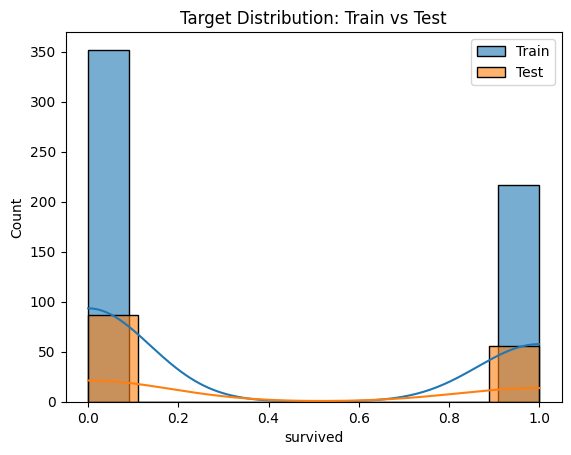

In [76]:
plt.figure()
sns.histplot(y_train_final_1, kde=True, label="Train", alpha=0.6)
sns.histplot(y_val_1, kde=True, label="Test", alpha=0.6)

plt.title("Target Distribution: Train vs Test")
plt.legend()
plt.show()

In [ ]:
# Apply train_test_split using a fixed random_state
# Repeat split to confirm reproducibility

In [22]:
# Visualizing Target Distribution

# Plot distribution of target variable

# Compare target distribution in train and test datasets